In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Worker Geospatial Matching Dataset

df = pd.read_csv(
    "../../datasets/worker_geospatial_matching_data.csv"
)

print("--- Worker Geospatial Matching Data ---")
print(f"Dataset Shape: {df.shape}")

print("\nData Types:")
print(df.dtypes)

display(df.head())

--- Worker Geospatial Matching Data ---
Dataset Shape: (2000, 8)

Data Types:
Worker_Experience_Years         int64
Worker_Primary_Skills          object
Job_Required_Skill             object
Distance_KM                   float64
Worker_Historical_Rating      float64
Farmer_Historical_Rating      float64
Historical_Acceptance_Rate    float64
Is_Successful_Match             int64
dtype: object


,Worker_Experience_Years,Worker_Primary_Skills,Job_Required_Skill,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match
0,10,"Seeding, Pesticide Spraying",Pruning,33.98,4.1,3.9,0.66,0
1,1,"Pesticide Spraying, Harvesting, Seeding",Seeding,19.70,4.0,3.6,0.61,1
2,13,"Pruning, Tractor Driving, Pesticide Spraying",Harvesting,17.08,3.6,3.8,0.32,0
3,1,"Seeding, Harvesting",Harvesting,2.14,4.5,4.9,0.47,1
4,9,"Seeding, Pesticide Spraying, Harvesting",Pesticide Spraying,14.30,4.4,3.7,0.87,1


In [3]:
print(df['Is_Successful_Match'].value_counts())
print("\nPercentages:")
print(df['Is_Successful_Match'].value_counts(normalize=True) * 100)

Is_Successful_Match
0    1147
1     853
Name: count, dtype: int64

Percentages:
Is_Successful_Match
0    57.35
1    42.65
Name: proportion, dtype: float64


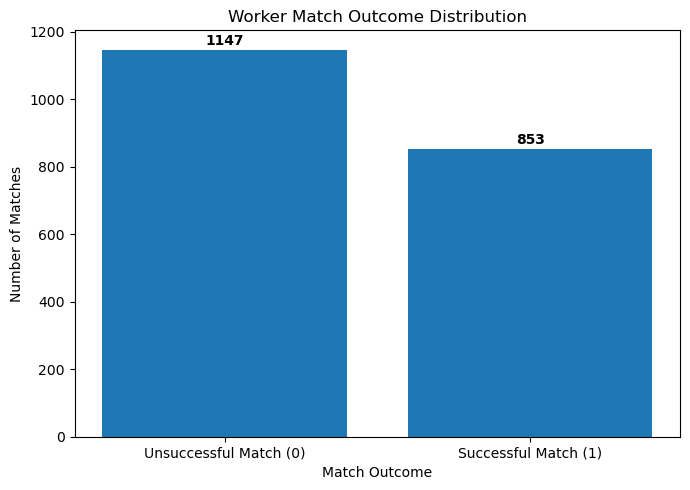

In [4]:
counts = df['Is_Successful_Match'].value_counts().sort_index()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Unsuccessful Match (0)', 'Successful Match (1)'],
    counts.values
)

plt.title('Worker Match Outcome Distribution')
plt.xlabel('Match Outcome')
plt.ylabel('Number of Matches')

# Add numbers on bars
for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(value),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

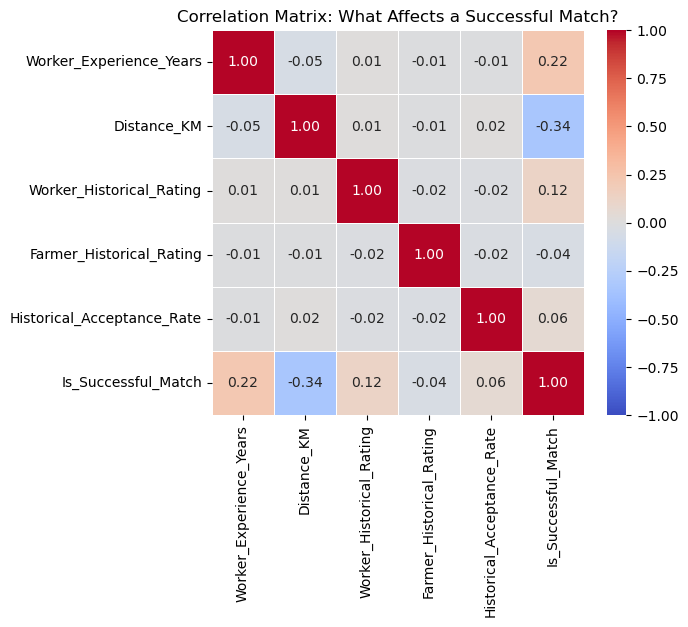

In [5]:
# 2. Select only numerical columns for correlation calculation
numeric_cols = [
    'Worker_Experience_Years', 'Distance_KM', 'Worker_Historical_Rating', 
    'Farmer_Historical_Rating', 'Historical_Acceptance_Rate', 'Is_Successful_Match'
]
corr_matrix = df[numeric_cols].corr()

# 3. Plot the correlation matrix focusing on what drives "Is_Successful_Match"
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: What Affects a Successful Match?')
plt.show()

## Correlation Analysis – What Affects Successful Worker Matching?

This correlation heatmap shows the relationship between the numerical features in the worker dataset and the target variable **`Is_Successful_Match`**.

###  Key Findings

* **Distance_KM → Successful Match: -0.34**

  * Distance has the strongest correlation with successful matching among the numerical features.
  * The negative correlation indicates that, in this dataset, successful matches tend to be associated with **shorter worker-to-job distances**.
  * This supports the use of distance as an important feature in the worker matching system.

* **Worker_Experience_Years → Successful Match: 0.22**

  * Experience has a positive relationship with successful matching.
  * Workers with more experience tend to be associated with successful matches more often.

* **Worker_Historical_Rating → Successful Match: 0.12**

  * Worker rating has a small positive relationship with successful matching.
  * Higher-rated workers show a slight tendency toward successful matches.

* **Historical_Acceptance_Rate → Successful Match: 0.06**

  * Acceptance rate has a very weak positive correlation with successful matching.
  * It may provide some information to the model, but its individual linear relationship with the target is small.

* **Farmer_Historical_Rating → Successful Match: -0.04**

  * This has a very weak negative correlation with successful matching.
  * Based on correlation alone, it does not appear to have a strong linear relationship with the target.

###  Important Interpretation

The correlation values show **linear relationships**, not causation. A correlation of `-0.34`, for example, does not mean that increasing distance directly causes a match to fail.

Also, the categorical variables such as **Worker Primary Skills** and **Job Required Skill** are not represented in this numerical correlation map. Their effect on matching will be investigated separately.

###  Conclusion

From the numerical features, **Distance_KM has the strongest relationship with `Is_Successful_Match`**, followed by **Worker Experience** and **Worker Historical Rating**.

Therefore, these features should be considered important inputs when developing the **Worker Matching Model**. The machine-learning model will evaluate these features together rather than relying on correlation values alone.


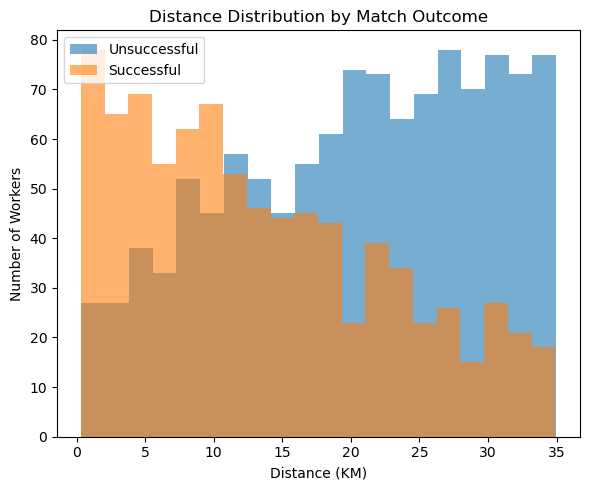

In [6]:
plt.figure(figsize=(6, 5))

for match_value, label in [(0, 'Unsuccessful'), (1, 'Successful')]:
    data = df[
        df['Is_Successful_Match'] == match_value
    ]['Distance_KM']

    plt.hist(
        data,
        bins=20,
        alpha=0.6,
        label=label
    )

plt.title('Distance Distribution by Match Outcome')
plt.xlabel('Distance (KM)')
plt.ylabel('Number of Workers')
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

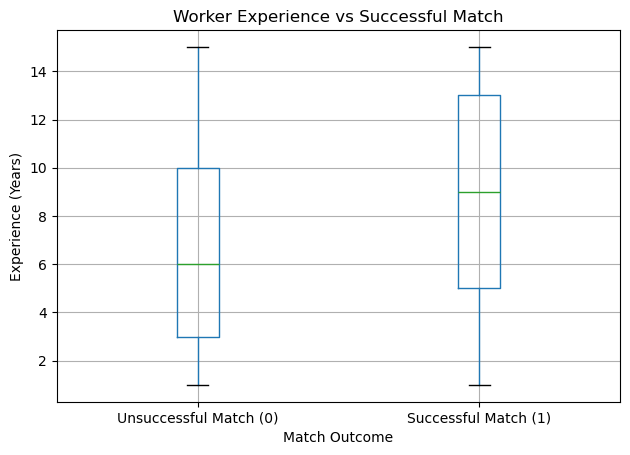

In [7]:
plt.figure(figsize=(9, 6))

df.boxplot(
    column='Worker_Experience_Years',
    by='Is_Successful_Match'
)

plt.title('Worker Experience vs Successful Match')
plt.suptitle('')
plt.xlabel('Match Outcome')
plt.ylabel('Experience (Years)')

plt.xticks(
    [1, 2],
    ['Unsuccessful Match (0)', 'Successful Match (1)']
)

plt.tight_layout()
plt.show()

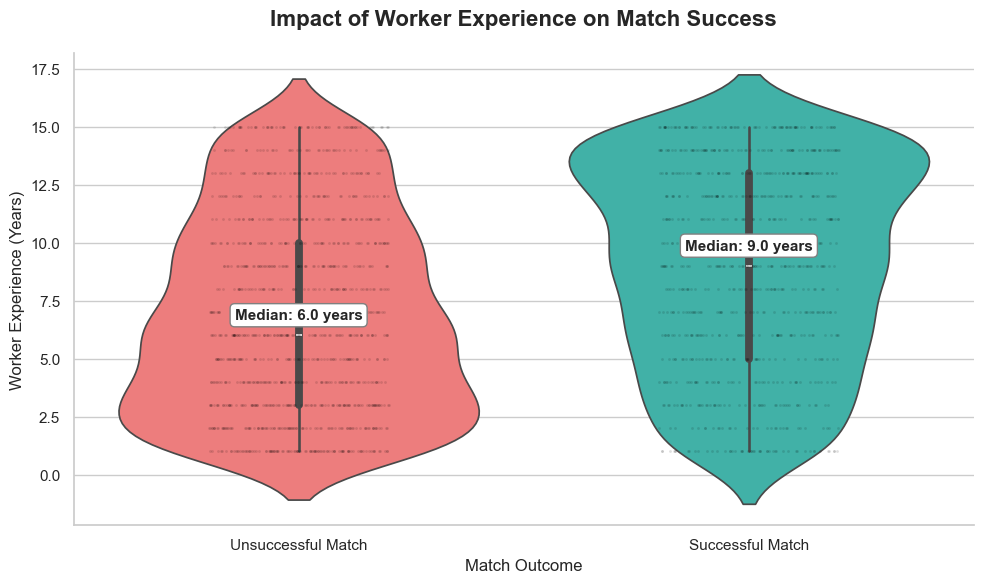

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Violin plot
ax = sns.violinplot(
    data=df,
    x="Is_Successful_Match",
    y="Worker_Experience_Years",
    hue="Is_Successful_Match",
    palette=["#FF6B6B", "#2EC4B6"],
    inner="box",
    legend=False
)

# Show individual observations
sns.stripplot(
    data=df,
    x="Is_Successful_Match",
    y="Worker_Experience_Years",
    color="black",
    alpha=0.12,
    jitter=0.2,
    size=2
)

# Calculate median values
medians = df.groupby(
    "Is_Successful_Match"
)["Worker_Experience_Years"].median()

# Display median labels
for i, median in enumerate(medians):
    ax.text(
        i, median + 0.7,
        f"Median: {median:.1f} years",
        ha="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="gray",
            boxstyle="round,pad=0.3"
        )
    )

plt.xticks(
    [0, 1],
    ["Unsuccessful Match", "Successful Match"]
)

plt.title(
    "Impact of Worker Experience on Match Success",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Match Outcome", fontsize=12)
plt.ylabel("Worker Experience (Years)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

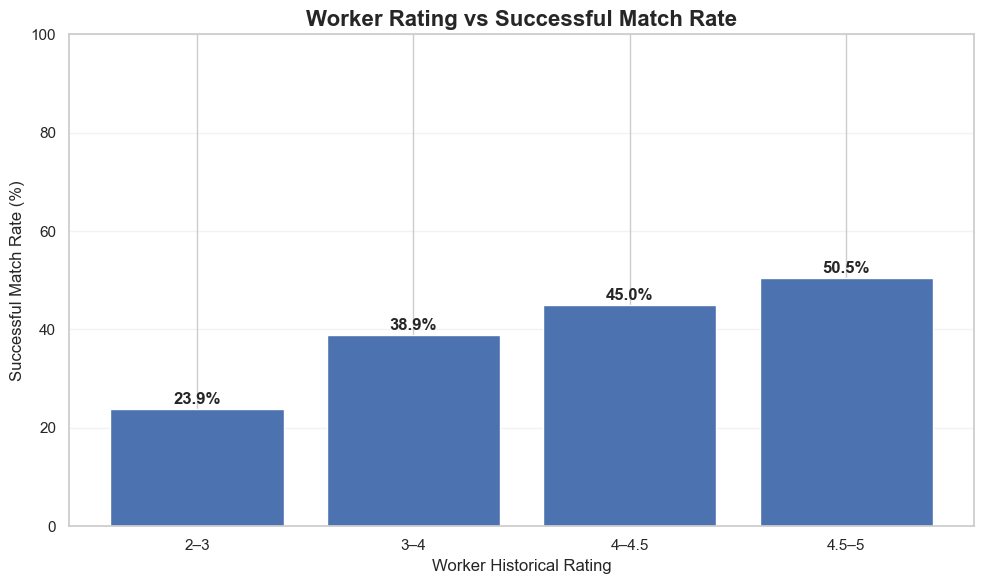

In [9]:
# Create rating bands
df['Rating_Band'] = pd.cut(
    df['Worker_Historical_Rating'],
    bins=[0, 2, 3, 4, 4.5, 5],
    labels=[
        '0–2',
        '2–3',
        '3–4',
        '4–4.5',
        '4.5–5'
    ],
    include_lowest=True
)

# Calculate successful match percentage for each rating band
rating_success = (
    df.groupby('Rating_Band', observed=True)['Is_Successful_Match']
    .mean()
    .mul(100)
    .reset_index(name='Success_Rate')
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    rating_success['Rating_Band'].astype(str),
    rating_success['Success_Rate']
)

# Add percentage labels
for bar, value in zip(bars, rating_success['Success_Rate']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.title(
    'Worker Rating vs Successful Match Rate',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Worker Historical Rating')
plt.ylabel('Successful Match Rate (%)')

plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [10]:
df.describe()

,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000
mean,7.810500,17.42304,3.995500,4.197550,0.649745,0.426500
std,4.395253,9.93401,0.580007,0.466088,0.202028,0.494692
min,1.000000,0.30000,3.000000,3.400000,0.300000,0.000000
25%,4.000000,8.86500,3.500000,3.800000,0.470000,0.000000
50%,8.000000,17.37000,4.000000,4.200000,0.650000,0.000000
75%,12.000000,26.03500,4.500000,4.600000,0.830000,1.000000
max,15.000000,34.98000,5.000000,5.000000,1.000000,1.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Worker_Experience_Years     2000 non-null   int64   
 1   Worker_Primary_Skills       2000 non-null   object  
 2   Job_Required_Skill          2000 non-null   object  
 3   Distance_KM                 2000 non-null   float64 
 4   Worker_Historical_Rating    2000 non-null   float64 
 5   Farmer_Historical_Rating    2000 non-null   float64 
 6   Historical_Acceptance_Rate  2000 non-null   float64 
 7   Is_Successful_Match         2000 non-null   int64   
 8   Rating_Band                 2000 non-null   category
dtypes: category(1), float64(4), int64(2), object(2)
memory usage: 127.3+ KB


### Job_Required_Skill → One-Hot Encoding

In [12]:
df.columns.tolist()

['Worker_Experience_Years',
 'Worker_Primary_Skills',
 'Job_Required_Skill',
 'Distance_KM',
 'Worker_Historical_Rating',
 'Farmer_Historical_Rating',
 'Historical_Acceptance_Rate',
 'Is_Successful_Match',
 'Rating_Band']

In [13]:
# One-Hot Encoding for Job_Required_Skill

job_skill_encoded = pd.get_dummies(
    df['Job_Required_Skill'],
    prefix='Required_Skill',
    dtype=int
)

print("✓ Job_Required_Skill encoded successfully!")

print("\nEncoded columns:")
print(job_skill_encoded.columns.tolist())

display(job_skill_encoded.head())

✓ Job_Required_Skill encoded successfully!

Encoded columns:
['Required_Skill_Harvesting', 'Required_Skill_Irrigation Setup', 'Required_Skill_Pesticide Spraying', 'Required_Skill_Pruning', 'Required_Skill_Seeding', 'Required_Skill_Tractor Driving']


,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving
0,0,0,0,1,0,0
1,0,0,0,0,1,0
2,1,0,0,0,0,0
3,1,0,0,0,0,0
4,0,0,1,0,0,0


In [14]:
# Remove original categorical column
df.drop(columns=['Job_Required_Skill'], inplace=True)

# Add encoded columns to df
df[job_skill_encoded.columns] = job_skill_encoded

print("✓ Job_Required_Skill replaced with One-Hot Encoded columns!")

display(df.head())

✓ Job_Required_Skill replaced with One-Hot Encoded columns!


,Worker_Experience_Years,Worker_Primary_Skills,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match,Rating_Band,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving
0,10,"Seeding, Pesticide Spraying",33.98,4.1,3.9,0.66,0,4–4.5,0,0,0,1,0,0
1,1,"Pesticide Spraying, Harvesting, Seeding",19.70,4.0,3.6,0.61,1,3–4,0,0,0,0,1,0
2,13,"Pruning, Tractor Driving, Pesticide Spraying",17.08,3.6,3.8,0.32,0,3–4,1,0,0,0,0,0
3,1,"Seeding, Harvesting",2.14,4.5,4.9,0.47,1,4–4.5,1,0,0,0,0,0
4,9,"Seeding, Pesticide Spraying, Harvesting",14.30,4.4,3.7,0.87,1,4–4.5,0,0,1,0,0,0


In [15]:
# Multi-Label Encoding for Worker_Primary_Skills

worker_skills_encoded = df['Worker_Primary_Skills'].str.get_dummies(sep=',')

# Remove extra spaces from column names
worker_skills_encoded.columns = (
    worker_skills_encoded.columns.str.strip()
)

# Handle duplicate skill columns, if any
worker_skills_encoded = (
    worker_skills_encoded.T
    .groupby(level=0)
    .max()
    .T
)

print("✓ Worker_Primary_Skills encoded successfully!")

print("\nEncoded columns:")
print(worker_skills_encoded.columns.tolist())

display(worker_skills_encoded.head())

✓ Worker_Primary_Skills encoded successfully!

Encoded columns:
['Harvesting', 'Irrigation Setup', 'Pesticide Spraying', 'Pruning', 'Seeding', 'Tractor Driving']


,Harvesting,Irrigation Setup,Pesticide Spraying,Pruning,Seeding,Tractor Driving
0,0,0,1,0,1,0
1,1,0,1,0,1,0
2,0,0,1,1,0,1
3,1,0,0,0,1,0
4,1,0,1,0,1,0


In [16]:
# Remove original Worker_Primary_Skills column
df.drop(columns=['Worker_Primary_Skills'], inplace=True)

# Add multi-label encoded columns directly to df
df[worker_skills_encoded.columns] = worker_skills_encoded

print("✓ Original Worker_Primary_Skills removed!")
print("✓ Multi-label encoded columns added to df!")

display(df.head())

✓ Original Worker_Primary_Skills removed!
✓ Multi-label encoded columns added to df!


,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Is_Successful_Match,Rating_Band,Required_Skill_Harvesting,Required_Skill_Irrigation Setup,Required_Skill_Pesticide Spraying,Required_Skill_Pruning,Required_Skill_Seeding,Required_Skill_Tractor Driving,Harvesting,Irrigation Setup,Pesticide Spraying,Pruning,Seeding,Tractor Driving
0,10,33.98,4.1,3.9,0.66,0,4–4.5,0,0,0,1,0,0,0,0,1,0,1,0
1,1,19.70,4.0,3.6,0.61,1,3–4,0,0,0,0,1,0,1,0,1,0,1,0
2,13,17.08,3.6,3.8,0.32,0,3–4,1,0,0,0,0,0,0,0,1,1,0,1
3,1,2.14,4.5,4.9,0.47,1,4–4.5,1,0,0,0,0,0,1,0,0,0,1,0
4,9,14.30,4.4,3.7,0.87,1,4–4.5,0,0,1,0,0,0,1,0,1,0,1,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Worker_Experience_Years            2000 non-null   int64   
 1   Distance_KM                        2000 non-null   float64 
 2   Worker_Historical_Rating           2000 non-null   float64 
 3   Farmer_Historical_Rating           2000 non-null   float64 
 4   Historical_Acceptance_Rate         2000 non-null   float64 
 5   Is_Successful_Match                2000 non-null   int64   
 6   Rating_Band                        2000 non-null   category
 7   Required_Skill_Harvesting          2000 non-null   int64   
 8   Required_Skill_Irrigation Setup    2000 non-null   int64   
 9   Required_Skill_Pesticide Spraying  2000 non-null   int64   
 10  Required_Skill_Pruning             2000 non-null   int64   
 11  Required_Skill_Seeding             2000 non

In [18]:
from sklearn.preprocessing import StandardScaler

# Numerical features
numeric_features = [
    'Worker_Experience_Years',
    'Distance_KM',
    'Worker_Historical_Rating',
    'Farmer_Historical_Rating',
    'Historical_Acceptance_Rate'
]

# Create scaler
scaler = StandardScaler()

# Fit and transform numerical features
X_numeric_scaled = scaler.fit_transform(
    df[numeric_features]
)

print("✓ Numerical features scaled successfully!")

display(pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_features
).head())

✓ Numerical features scaled successfully!


,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate
0,0.498276,1.667111,0.180215,-0.638559,0.050773
1,-1.549900,0.229266,0.007760,-1.282376,-0.196780
2,1.181001,-0.034541,-0.682059,-0.853165,-1.632585
3,-1.549900,-1.538841,0.870035,1.507497,-0.889927
4,0.270701,-0.314457,0.697580,-1.067770,1.090494


In [19]:
print(pd.DataFrame(
    X_numeric_scaled,
    columns=numeric_features
).describe())

       Worker_Experience_Years   Distance_KM  Worker_Historical_Rating  \
count             2.000000e+03  2.000000e+03              2.000000e+03   
mean             -7.371881e-17 -3.019807e-17              2.948752e-16   
std               1.000250e+00  1.000250e+00              1.000250e+00   
min              -1.549900e+00 -1.724110e+00             -1.716788e+00   
25%              -8.671749e-01 -8.617044e-01             -8.545139e-01   
50%               4.312548e-02 -5.340569e-03              7.760469e-03   
75%               9.534258e-01  8.671336e-01              8.700348e-01   
max               1.636151e+00  1.767801e+00              1.732309e+00   

       Farmer_Historical_Rating  Historical_Acceptance_Rate  
count              2.000000e+03                2.000000e+03  
mean               6.963319e-16               -8.082424e-17  
std                1.000250e+00                1.000250e+00  
min               -1.711587e+00               -1.731606e+00  
25%               -8.53

In [20]:
from sklearn.pipeline import Pipeline
numeric_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    MultiLabelBinarizer
)

from sklearn.base import BaseEstimator, TransformerMixin

In [22]:
# Numerical Features
numeric_features = [
    'Worker_Experience_Years',
    'Distance_KM',
    'Worker_Historical_Rating',
    'Farmer_Historical_Rating',
    'Historical_Acceptance_Rate'
]

# Categorical Features
categorical_features = [
    'Job_Required_Skill'
]

# Multi-Label Features
multilabel_features = [
    'Worker_Primary_Skills'
]

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)
print("Multi-Label Features:", multilabel_features)

Numerical Features: ['Worker_Experience_Years', 'Distance_KM', 'Worker_Historical_Rating', 'Farmer_Historical_Rating', 'Historical_Acceptance_Rate']
Categorical Features: ['Job_Required_Skill']
Multi-Label Features: ['Worker_Primary_Skills']


In [23]:
numeric_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

print("Numerical Pipeline Created Successfully!")

Numerical Pipeline Created Successfully!


In [24]:
categorical_pipeline = Pipeline(
    steps=[
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)

print("Categorical Encoding Pipeline Created Successfully!")

Categorical Encoding Pipeline Created Successfully!


In [25]:
class MultiLabelSkillsEncoder(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.encoder = MultiLabelBinarizer()

    def fit(self, X, y=None):

        skills = pd.Series(
            np.asarray(X).ravel()
        ).fillna("")

        skill_lists = skills.apply(
            lambda x: [
                skill.strip()
                for skill in str(x).split(",")
                if skill.strip()
            ]
        )

        self.encoder.fit(skill_lists)

        return self

    def transform(self, X):

        skills = pd.Series(
            np.asarray(X).ravel()
        ).fillna("")

        skill_lists = skills.apply(
            lambda x: [
                skill.strip()
                for skill in str(x).split(",")
                if skill.strip()
            ]
        )

        return self.encoder.transform(skill_lists)

    def get_feature_names_out(self, input_features=None):

        return np.array([
            f"Worker_Skill_{skill}"
            for skill in self.encoder.classes_
        ])

In [26]:
multilabel_pipeline = Pipeline(
    steps=[
        ('multilabel', MultiLabelSkillsEncoder())
    ]
)

print("Multi-Label Encoding Pipeline Created Successfully!")

Multi-Label Encoding Pipeline Created Successfully!


In [27]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            'numeric',
            numeric_pipeline,
            numeric_features
        ),

        (
            'categorical',
            categorical_pipeline,
            categorical_features
        ),

        (
            'multilabel',
            multilabel_pipeline,
            multilabel_features
        )

    ],
    remainder='drop'
)

print("Complete Preprocessing Pipeline Created Successfully!")

Complete Preprocessing Pipeline Created Successfully!


In [28]:
from sklearn import set_config

# Enable visual representation of pipelines
set_config(display='diagram')

print("Pipeline Visualization Enabled!")

Pipeline Visualization Enabled!


In [29]:
display(preprocessor)

,transformers,"[('numeric', ...), ('categorical', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [30]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All ML libraries imported successfully!")

All ML libraries imported successfully!


In [31]:
# Reload original dataset
df_model = pd.read_csv(
    "../../datasets/worker_geospatial_matching_data.csv"
)

print("Original Dataset Loaded Successfully!")

print("Dataset Shape:", df_model.shape)

print("\nOriginal Columns:")
print(df_model.columns.tolist())

Original Dataset Loaded Successfully!
Dataset Shape: (2000, 8)

Original Columns:
['Worker_Experience_Years', 'Worker_Primary_Skills', 'Job_Required_Skill', 'Distance_KM', 'Worker_Historical_Rating', 'Farmer_Historical_Rating', 'Historical_Acceptance_Rate', 'Is_Successful_Match']


In [32]:
# Input features
X = df_model[
    numeric_features +
    categorical_features +
    multilabel_features
].copy()

# Target variable
y = df_model['Is_Successful_Match'].copy()

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

Features Shape: (2000, 7)
Target Shape: (2000,)


,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Job_Required_Skill,Worker_Primary_Skills
0,10,33.98,4.1,3.9,0.66,Pruning,"Seeding, Pesticide Spraying"
1,1,19.70,4.0,3.6,0.61,Seeding,"Pesticide Spraying, Harvesting, Seeding"
2,13,17.08,3.6,3.8,0.32,Harvesting,"Pruning, Tractor Driving, Pesticide Spraying"
3,1,2.14,4.5,4.9,0.47,Harvesting,"Seeding, Harvesting"
4,9,14.30,4.4,3.7,0.87,Pesticide Spraying,"Seeding, Pesticide Spraying, Harvesting"


## Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Completed Successfully!")

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Train-Test Split Completed Successfully!

Training Data: (1600, 7)
Testing Data: (400, 7)

Training Target Distribution:
Is_Successful_Match
0    918
1    682
Name: count, dtype: int64

Testing Target Distribution:
Is_Successful_Match
0    229
1    171
Name: count, dtype: int64


##  Define Our 5 ML Models

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Define 5 Classification Models

models = {

    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5
    ),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

}

print("Total Models:", len(models))
print("\nModels Ready for Training:")

for i, model_name in enumerate(models.keys(), 1):
    print(f"{i}. {model_name}")

Total Models: 5

Models Ready for Training:
1. Logistic Regression
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Gradient Boosting


Fold Cross-Validation

Manam training dataset ni 5 folds ga divide chestham. Prathi model 5 different training-validation combinations meeda evaluate avutundi.

StratifiedKFold?

Mana dataset lo successful and unsuccessful matches proportions maintain cheyadaniki use chestham

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

print("Pipeline and Cross-Validation imported successfully!")

Pipeline and Cross-Validation imported successfully!


In [36]:
from sklearn.model_selection import StratifiedKFold

# Create 5-Fold Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross-Validation Created Successfully!")

5-Fold Cross-Validation Created Successfully!


In [37]:
print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [38]:
import warnings
warnings.filterwarnings("ignore")

## Train All 5 Models Using Simple Pipeline

In [39]:
# Store model results
results = []

# Store trained pipelines
trained_pipelines = {}

# Train all 5 models
for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    # Simple ML Pipeline
    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ]
    )

    # 5-Fold Cross-Validation
    scores = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        },
        n_jobs=1,
        error_score='raise'
    )

    # Train on complete training dataset
    model_pipeline.fit(
        X_train,
        y_train
    )

    # Save trained pipeline in memory
    trained_pipelines[model_name] = model_pipeline

    # Store performance metrics
    results.append({

        'Model': model_name,

        'CV Accuracy': scores['test_accuracy'].mean(),

        'CV Precision': scores['test_precision'].mean(),

        'CV Recall': scores['test_recall'].mean(),

        'CV F1 Score': scores['test_f1'].mean(),

        'CV Std': scores['test_accuracy'].std()

    })

    print(
        f"Mean CV Accuracy: "
        f"{scores['test_accuracy'].mean():.4f}"
    )

    print(
        f"Mean CV F1 Score: "
        f"{scores['test_f1'].mean():.4f}"
    )

print("\nAll 5 Models Trained Successfully!")


Training: Logistic Regression
Mean CV Accuracy: 0.6969
Mean CV F1 Score: 0.6192

Training: K-Nearest Neighbors
Mean CV Accuracy: 0.6800
Mean CV F1 Score: 0.5907

Training: Decision Tree
Mean CV Accuracy: 0.6044
Mean CV F1 Score: 0.5301

Training: Random Forest
Mean CV Accuracy: 0.7175
Mean CV F1 Score: 0.6419

Training: Gradient Boosting
Mean CV Accuracy: 0.7644
Mean CV F1 Score: 0.7055

All 5 Models Trained Successfully!


In [40]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='CV Accuracy',
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        'CV Accuracy': '{:.4f}',
        'CV Precision': '{:.4f}',
        'CV Recall': '{:.4f}',
        'CV F1 Score': '{:.4f}',
        'CV Std': '{:.4f}'
    })
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1 Score,CV Std
0,Gradient Boosting,0.7644,0.7552,0.6627,0.7055,0.0199
1,Random Forest,0.7175,0.6990,0.5938,0.6419,0.0131
2,Logistic Regression,0.6969,0.6674,0.5777,0.6192,0.0208
3,K-Nearest Neighbors,0.6800,0.6477,0.5439,0.5907,0.0240
4,Decision Tree,0.6044,0.5364,0.5250,0.5301,0.0306


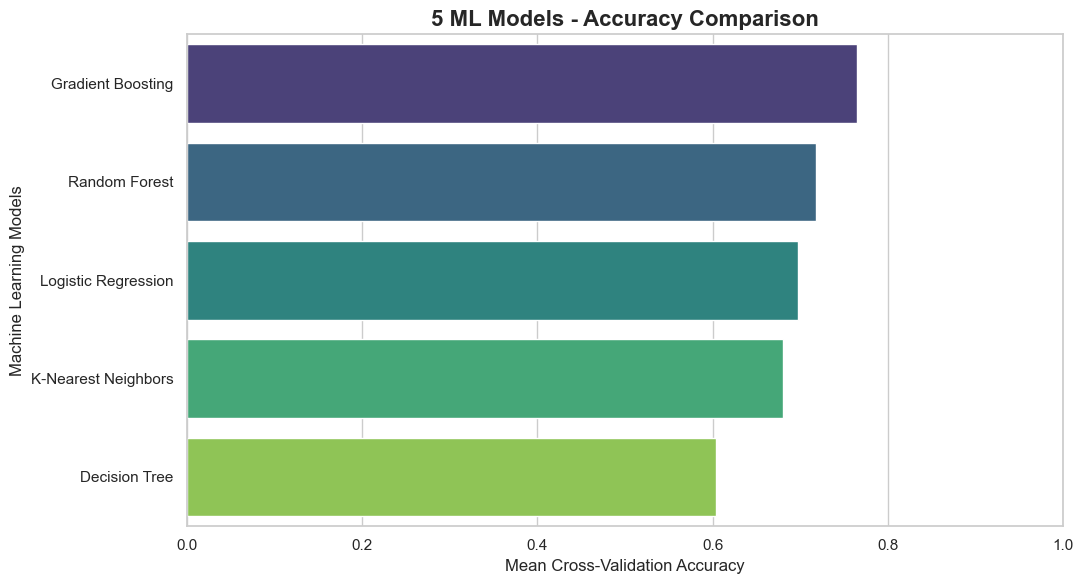

In [41]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=results_df,
    x='CV Accuracy',
    y='Model',
    hue='Model',
    palette='viridis',
    legend=False
)

plt.title(
    '5 ML Models - Accuracy Comparison',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Mean Cross-Validation Accuracy')
plt.ylabel('Machine Learning Models')

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

## Gradient Boosting Final Evaluation

In [42]:
# Select Gradient Boosting
selected_model_name = 'Gradient Boosting'

selected_pipeline = trained_pipelines[
    selected_model_name
]

# Test predictions
y_pred = selected_pipeline.predict(X_test)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Selected Model:", selected_model_name)

print("\nFinal Test Performance")

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred) * 100, 2),
    "%"
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred) * 100, 2),
    "%"
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred) * 100, 2),
    "%"
)

print(
    "F1 Score:",
    round(f1_score(y_test, y_pred) * 100, 2),
    "%"
)

Selected Model: Gradient Boosting

Final Test Performance
Accuracy: 77.5 %
Precision: 76.13 %
Recall: 69.01 %
F1 Score: 72.39 %


In [43]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Unsuccessful Match',
            'Successful Match'
        ]
    )
)

                    precision    recall  f1-score   support

Unsuccessful Match       0.78      0.84      0.81       229
  Successful Match       0.76      0.69      0.72       171

          accuracy                           0.78       400
         macro avg       0.77      0.76      0.77       400
      weighted avg       0.77      0.78      0.77       400



Metric

	

Interpretation




Accuracy

	

400 test records lo 77.5% predictions correct.




Precision

	

Successful match ani predict chesina records lo 76.13% correct.




Recall

	

Actual successful matches lo 69.01% ni identify chesindi.




F1 Score

	

Precision and Recall madhya balance ni measure chestundi.

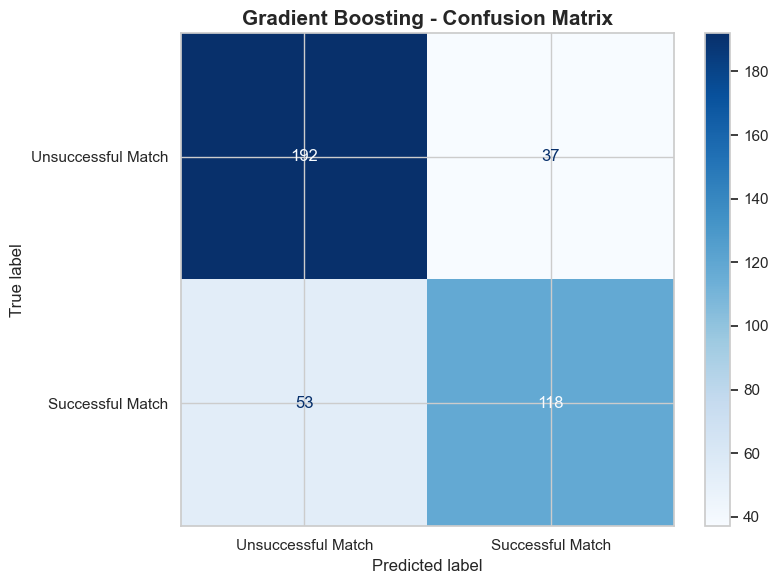

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Unsuccessful Match',
        'Successful Match'
    ]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    cmap='Blues',
    values_format='d',
    ax=ax
)

plt.title(
    'Gradient Boosting - Confusion Matrix',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Key observations

192 unsuccessful matches ni correctly identify chesindi.

118 successful matches ni correctly identify chesindi.

37 unsuccessful matches ni successful ani predict chesindi.

53 successful matches ni unsuccessful ani predict chesindi.

Mana model total 400 test records lo 310 correct predictions ichindi, resulting in 77.5% accuracy.

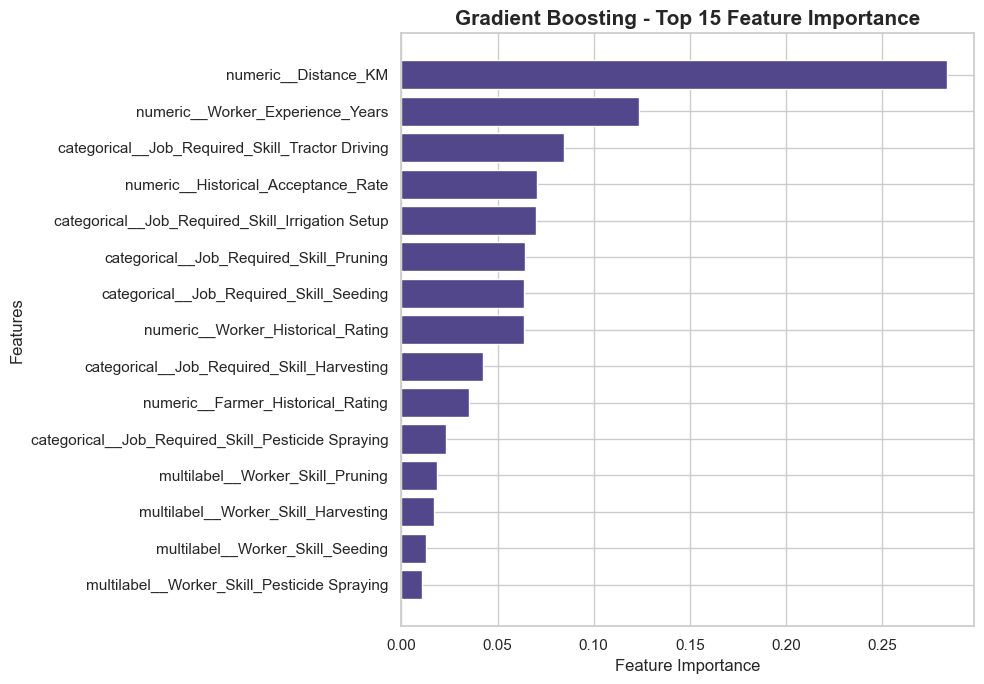

In [45]:
# Extract trained Gradient Boosting model
gb_model = selected_pipeline.named_steps['classifier']

# Get transformed feature names
feature_names = (
    selected_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 features
top_features = importance_df.head(15)

# Visualize
plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1],
    color='#51478A'
)

plt.title(
    'Gradient Boosting - Top 15 Feature Importance',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [46]:
import joblib
import os

from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

# Create final Gradient Boosting Pipeline
gradient_boosting_classifier = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Train the model
gradient_boosting_classifier.fit(X_train, y_train)

print("Gradient Boosting Classifier Trained Successfully!")

Gradient Boosting Classifier Trained Successfully!


In [47]:

# Save model
model_path = "../gradient_boosting_classifier.pkl"

joblib.dump(gradient_boosting_classifier, model_path)

print("Gradient Boosting Classifier Saved Successfully!")
print("Model Path:", model_path)

Gradient Boosting Classifier Saved Successfully!
Model Path: ../gradient_boosting_classifier.pkl


In [48]:
# Load saved model
loaded_model = joblib.load(model_path)

# Test prediction
test_prediction = loaded_model.predict(X_test)

print("Model Loaded Successfully!")
print("Test Predictions:", test_prediction[:10])

Model Loaded Successfully!
Test Predictions: [1 1 0 1 1 1 0 0 0 0]


In [49]:
# Sample Worker and Job Details
sample_data = pd.DataFrame([{
    'Worker_Experience_Years': 5,
    'Distance_KM': 8.5,
    'Worker_Historical_Rating': 4.5,
    'Farmer_Historical_Rating': 4.2,
    'Historical_Acceptance_Rate': 0.85,
    'Job_Required_Skill': 'Harvesting',
    'Worker_Primary_Skills': 'Harvesting, Seeding, Pruning'
}])

display(sample_data)

,Worker_Experience_Years,Distance_KM,Worker_Historical_Rating,Farmer_Historical_Rating,Historical_Acceptance_Rate,Job_Required_Skill,Worker_Primary_Skills
0,5,8.5,4.5,4.2,0.85,Harvesting,"Harvesting, Seeding, Pruning"


In [50]:
# Predict using trained model
prediction = loaded_model.predict(sample_data)

# Get prediction probability
probability = loaded_model.predict_proba(sample_data)

# Display results
if prediction[0] == 1:
    print("Prediction: Successful Match")
else:
    print("Prediction: Unsuccessful Match")

print(f"Match Probability: {probability[0][1] * 100:.2f}%")
print(f"Unsuccessful Match Probability: {probability[0][0] * 100:.2f}%")

Prediction: Successful Match
Match Probability: 82.67%
Unsuccessful Match Probability: 17.33%


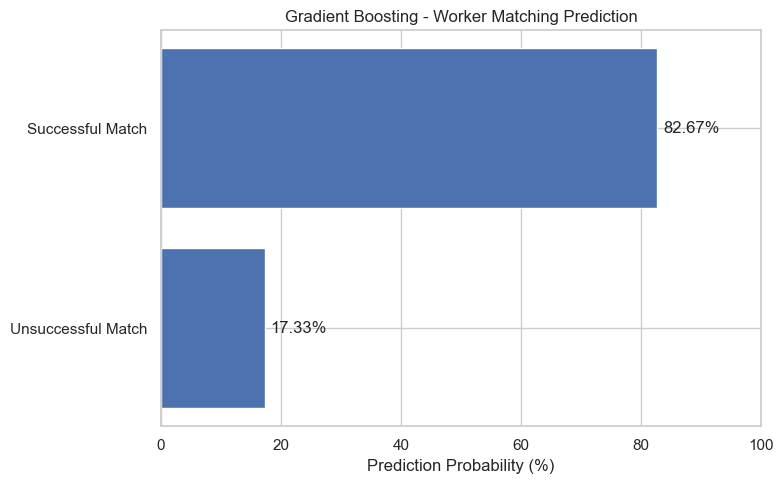

In [51]:
import matplotlib.pyplot as plt

labels = ['Unsuccessful Match', 'Successful Match']
values = probability[0] * 100

plt.figure(figsize=(8, 5))

bars = plt.barh(labels, values)

plt.xlabel('Prediction Probability (%)')
plt.title('Gradient Boosting - Worker Matching Prediction')
plt.xlim(0, 100)

for bar, value in zip(bars, values):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.2f}%',
        va='center'
    )

plt.tight_layout()
plt.show()